Copyright Matlantis Corp. as contributors to Matlantis contrib project

# Free Energy Calculation using MBAR

In umbrella sampling, we collected data by adding an artificial potential (harmonic oscillator) to the system, including unstable regions that are normally difficult to transition.
In this notebook, we use the MBAR (Multistate Bennett Acceptance Ratio) method to remove the bias of harmonic potential from the sampled trajectories and calculate the free energy profile (PMF: Potential of Mean Force).


## Library Installation and Import

In [ ]:
# Install the pymbar package if necessary
#! pip install pymbar

In [2]:
# Reference
#   https://weitsehsu.com/course/enhanced_sampling/us/
#   https://github.com/choderalab/pymbar-examples/blob/master/umbrella-sampling-pmf/umbrella-sampling.py

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymbar
from pymbar import timeseries 

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

****** PyMBAR will use 64-bit JAX! *******
* JAX is currently set to 32-bit bitsize *
* which is its default.                  *
*                                        *
* PyMBAR requires 64-bit mode and WILL   *
* enable JAX's 64-bit mode when called.  *
*                                        *
* This MAY cause problems with other     *
* Uses of JAX in the same code.          *
******************************************



## Check Distribution Overlap

To perform accurate free energy calculations, it is essential that there is overlap between the histograms of adjacent windows along the reaction coordinate.
Lack of overlap can lead to errors during analysis or failure of the calculation to converge.
If the overlap is insufficient, you may need to weaken the spring constant `KAPPA` or add new windows between them.

In [ ]:
# Load Trajectory
data = []

colvars = np.linspace(13.0, 33.0, num=41)
for cv_at in colvars:
    data.append(np.loadtxt(f"./output/04_umbrella_sampling/cv_{cv_at:.2f}/COLVAR_{cv_at:.2f}")[:, 1])

data = np.array(data)
data.shape

(39, 401)

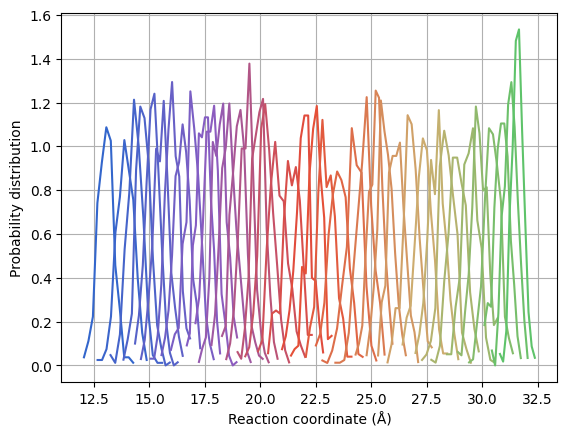

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
# Color gradation
stops = [
    (0.00, "#3366CC"),  # blue
    (0.25, "#8A5CC2"),  # purple
    (0.50, "#E64B35"),  # red
    (0.75, "#CDAE70"),  # Ochre
    (1.00, "#52C569"),  # green
]
cmap = LinearSegmentedColormap.from_list("blue-red-green", stops)

n_bins = data.shape[0]
for i, dat in enumerate(data):
    hist, bins = np.histogram(dat, bins=12, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    plt.plot(bin_centers, hist, linestyle='solid', label=str(i), color=cmap(i/n_bins), alpha=1.0)

plt.grid()
plt.xlabel('Reaction coordinate (Å)')
plt.ylabel('Probability distribution')
plt.show()

## Calculating Free Energy with MBAR

## Step 1. Setting Constants

Define the temperature and Boltzmann constant used in the simulation.
In MBAR calculations, energy is handled in units of $k_B T$ (dimensionless energy), so we pre-calculate the inverse temperature $\beta = 1 / k_B T$.

In [5]:
# Step1: Settings 
kB = 8.617333262e-5  # Boltzmann constant in eV/K
T  = 300.0           # assume a single temperature (in Kelvin)
beta = 1 / (kB * T)

### Step 2. Loading Data

Read the following data from each window's (z_at) directory:
* `COLVAR`: Time series data of the reaction coordinate (distance)
* `md-dyn.log`: Time series data of the potential energy

The loaded data is stored in lists for MBAR calculation.

In [ ]:
# Initialize lists for data storage
z_data = [] # Reaction Coordinate
w_data = [] # Bias Potential energy
U_data = [] # True Potential Energy (without Bias)
u_data = [] # Reduced Potential

beta_k = [] # Inverse temperature of each window
z0_k   = [] # Restraint center position of each window
K_k    = [] # Spring constant of each window

# Window settings (Same as simulation settings)
cv_min  = 13.0
cv_max  = 32.1
cv_step = 0.5
KAPPA   = 0.2


# kappa = 2.2 eV
for cv_at in np.arange(cv_min, cv_max, cv_step):
    # Load trajectory
    path_data = f"./output/04_umbrella_sampling/cv_{cv_at:.2f}"
    us_data   = np.loadtxt(f"{path_data}/COLVAR_{cv_at:.2f}")
    pot_data  = np.loadtxt(f"{path_data}/md-dyn.log", skiprows=1)[:, 2]  # potential energy

    K_k.append(KAPPA)
    z0_k.append(cv_at)
    beta_k.append(beta)

    z_data.append(us_data[1:, 1])  # reaction coordinate
    w_data.append(us_data[1:, 2])  # bias potentia.
    U_data.append(pot_data)
    u_data.append(pot_data * beta) # reduced potential for system


K_k    = np.array(K_k)
z0_k   = np.array(z0_k)
beta_k = np.array(beta_k)

z_data = np.array(z_data)
w_data = np.array(w_data)
U_data = np.array(U_data)
u_data = np.array(u_data)

K_k.shape, z0_k.shape, beta_k.shape, z_data.shape, w_data.shape, w_data.shape, U_data.shape, u_data.shape

((39,), (39,), (39,), (39, 400), (39, 400), (39, 400), (39, 401), (39, 401))

In [7]:
K_k, len(K_k)

(array([0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
        0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2,
        0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2]),
 39)

### Step 3. Data Pre-processing (Subsampling)

Since MD simulation data has time-series correlation (structures are similar to those immediately preceding them), they cannot be regarded as independent samples.
We use `pymbar.timeseries` to calculate "Statistical Inefficiency" and extract only highly independent data by thinning out strongly correlated samples. This process is important for accurate error evaluation.

In [8]:
# Parameters for CV
K      = K_k.shape[0]    # number of umbrellas
N_max  = z_data.shape[1] # maximum number of snapshots/simulation
z_min  = 13.5            # minimum of the CV for plotting the FES
z_max  = 32.5            # maximum of the CV for plotting the FES
nbins  =   50            # number of bins for 1D PMF

# Allocate storage for simulation data
N_k    = np.zeros([K], np.int32)          # N_k[k] is the number of snapshots from umbrella simulation k
g_k    = np.zeros([K], np.float32)        # g_k[k] is the statistical inefficiency of umbrella simulation k
z_kn   = np.zeros([K, N_max], np.float64) # z_kn[k,n] is the pulled atom position (in Angstrom) for snapshot n from umbrella simulation k
W_kn   = np.zeros([K, N_max], np.float64) # W_kn[k,n] is the umbrella potential energy for snapshot n from umbrella simulation k
U_kn   = np.zeros([K, N_max], np.float64) # U_kn[k,n] is the potential energy without umbrella restraints
u_kn   = np.zeros([K, N_max], np.float64) # u_kn[k,n] is the reduced potential energy for snapshot n from umbrella simulation k

In [9]:
for k in range(K):

    z_full = z_data[k, :]   # reaction coordinates
    W_full = w_data[k, :]   # bias energy
    U_full = U_data[k, :]   # potential energy
    u_full = u_data[k, :]   # reduced potential energy


    # Subsampling
    g_k[k]  = timeseries.statistical_inefficiency(z_full)
    indices = timeseries.subsample_correlated_data(z_full, g=g_k[k])
    N_k[k]  = len(indices)

    U_kn[k, :N_k[k]] = U_full[indices]
    u_kn[k, :N_k[k]] = u_full[indices]
    z_kn[k, :N_k[k]] = z_full[indices]
    W_kn[k, :N_k[k]] = W_full[indices]

### Step 4. Calculation of Reduced Potential Matrix

We calculate how much energy a structure $n$ obtained in window $k$ would have if it were under the conditions of another window $l$ (Reduced Potential $u_{k,l,n}$).

This allows for probability weighting between different biases.

$$u_{k,l,n} = \beta [ U(x_{kn}) + V_l(x_{kn}) ]$$

Here $V_l$ is the bias potential (harmonic oscillator) in window $l$.

In [10]:
# Bin the data
bin_center_i = np.zeros([nbins], np.float64)
bin_edges    = np.linspace(z_min, z_max, nbins + 1)
for i in range(nbins):
    bin_center_i[i] = 0.5 * (bin_edges[i] + bin_edges[i + 1])

In [11]:
print("Edges range:", bin_edges.min(), bin_edges.max())
print("Query range:", bin_center_i.min(), bin_center_i.max())

Edges range: 13.5 32.5
Query range: 13.690000000000001 32.31


In [12]:
# Evaluate reduced energies in all umbrellas
N_max = np.max(N_k)             # shorten the array size
u_kln = np.zeros([K, K, N_max]) # u_kln[k,l,n] is the reduced potential energy of snapshot n from umbrella simulation k evaluated at umbrella l

for k, z0 in enumerate(z0_k):
    for n in range(N_k[k]):
        for l in range(K):
            u_kln[k, l, n] = beta_k[k] * (U_kn[k, n] + 0.5 * K_k[l] * (z_kn[k, n] - z0_k[l])**2)

### Step 5. Calculation of Free Energy Profile by MBAR

Use the `pymbar.FES` class to perform reweighting and calculate the free energy profile with the bias removed.

In [13]:
# Step 5: Compute, output, and plot the FES
fes = pymbar.FES(u_kln, N_k, verbose=True)
z_n = pymbar.utils.kn_to_n(z_kn, N_k=N_k)

histo_params = {'bin_edges': bin_edges}
fes.generate_fes(u_kn, z_n, fes_type='histogram', histogram_parameters=histo_params)
results = fes.get_fes(bin_center_i, reference_point="from-lowest", uncertainty_method="analytical")

f_i  = results["f_i"]
df_i = results["df_i"]

os.makedirs('output/05_mbar', exist_ok=True)
with open('output/05_mbar/fes.dat', 'w') as f:
    f.write("# free energy profile (in units of kT), from histogramming\n")
    f.write(f"# {'bin':>8s} {'f':>8s} {'df':>8s} \n")
    for i in range(nbins):
       f.write(f"{bin_center_i[i]:>8.3f} {f_i[i]:>8.3f} {df_i[i]:>8.3f} \n")


******* JAX 64-bit mode is now on! *******
*     JAX is now set to 64-bit mode!     *
*   This MAY cause problems with other   *
*      uses of JAX in the same code.     *
******************************************



### Step 6. Visualization of Results

Plot the calculated free energy profile. The light blue band represents the range of calculated statistical error.

#### Plot in kcal/mol units

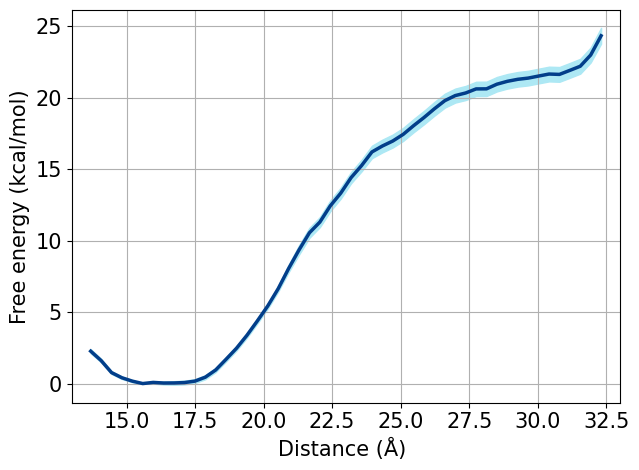

In [14]:
# Step 6: Plot (kcal/mol)

data = np.loadtxt('./output/05_mbar/fes.dat')

bin_center_i = data[:, 0]
f_i  = data[:, 1]
df_i = data[:, 2]

fig, ax = plt.subplots()
kT2kcalmol = 0.5961

fi_kcalmol  = f_i  * kT2kcalmol
dfi_kcalmol = df_i * kT2kcalmol

ax.plot(bin_center_i, fi_kcalmol, color="#023e8a", linewidth=2.5)
ax.fill_between(bin_center_i, fi_kcalmol - dfi_kcalmol, fi_kcalmol + dfi_kcalmol, color="#ade8f4")

ax.set_xlim(13, 33)


ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.set_xlabel('Distance (Å) ', fontsize=15)
ax.set_ylabel('Free energy (kcal/mol)',     fontsize=15)
plt.grid()

fig.tight_layout()
plt.savefig('./output/05_mbar/mbar_free_energy_kcalmol.png')
plt.savefig('./output/05_mbar/mbar_free_energy_kcalmol.pdf')

#### Plot in kJ/mol units

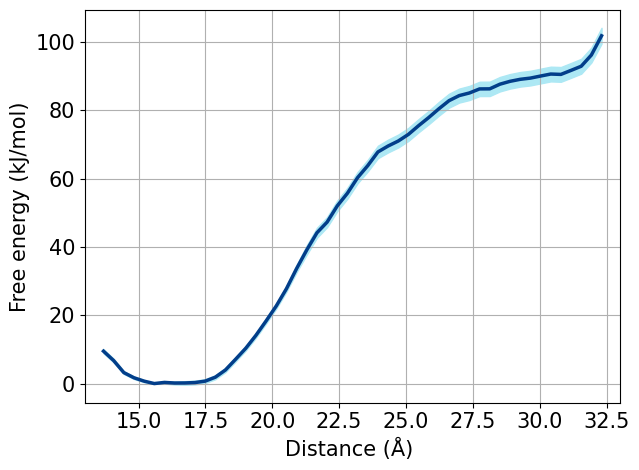

In [15]:
# Step 6: Plot (kcal/mol)

data = np.loadtxt('./output/05_mbar/fes.dat')

bin_center_i = data[:, 0]
f_i  = data[:, 1]
df_i = data[:, 2]

fig, ax = plt.subplots()
kT2kcalmol = 0.5961 * 4.1868

fi_kcalmol  = f_i  * kT2kcalmol
dfi_kcalmol = df_i * kT2kcalmol

ax.plot(bin_center_i, fi_kcalmol, color="#023e8a", linewidth=2.5)
ax.fill_between(bin_center_i, fi_kcalmol - dfi_kcalmol, fi_kcalmol + dfi_kcalmol, color="#ade8f4")

ax.set_xlim(13, 33)
#ax.set_ylim(-0.1, 26.0)
#ax.set_xticks((-2.0, -1.5, -1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0))

ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.set_xlabel('Distance (Å) ', fontsize=15)
ax.set_ylabel('Free energy (kJ/mol)',     fontsize=15)
plt.grid()

fig.tight_layout()
plt.savefig('./output/05_mbar/mbar_free_energy_kjmol.png')
plt.savefig('./output/05_mbar/mbar_free_energy_kjmol.pdf')